# E2 — Notebook 03: Estimación PSM y AIPW
## LaLonde/NSW — ICA 2026-I

**Objetivo:** Estimar el ATT con PSM (Dehejia & Wahba 1999) y AIPW (estimador doblemente robusto) en los datasets CPS1 y PSID1. Comparar con el benchmark RCT.

**Benchmark RCT:** ATT = $1,794 (SE ≈ $632), IC 95%: [$555, $3,033] — LaLonde (1986)

In [1]:
import os, warnings
warnings.filterwarnings('ignore')
from pathlib import Path
_root = Path(os.getcwd())
while _root != _root.parent and not (_root / 'pyproject.toml').exists():
    _root = _root.parent
os.chdir(_root)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lalonde_nsw.data import smd, COVARIABLES
from lalonde_nsw.estimators import estimar_psm, estimar_aipw, tabla_resultados
from lalonde_nsw.visualization import love_plot, overlap_plot, forest_plot
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')

# Cargar datasets procesados
processed = Path('data/processed')
df_exp   = pd.read_parquet(processed / 'experimental.parquet')
df_cps1  = pd.read_parquet(processed / 'obs_cps1.parquet')
df_psid1 = pd.read_parquet(processed / 'obs_psid1.parquet')
print(f'Cargados: exp={len(df_exp)}, cps1={len(df_cps1)}, psid1={len(df_psid1)}')

Cargados: exp=445, cps1=16177, psid1=2675


## 1. PSM — Propensity Score Matching

Matching 1:1 sin reemplazo usando LogisticRegression para estimar el PS.
SE estimado por bootstrap (500 réplicas). Basado en Dehejia & Wahba (1999).

In [2]:
print('=== PSM en CPS1 ===')
psm_cps1 = estimar_psm(df_cps1, random_state=RANDOM_STATE)
print(f"ATT = ${psm_cps1['ATT']:,.0f}")
print(f"SE  = ${psm_cps1['SE']:,.0f}")
print(f"IC 95% = [${psm_cps1['CI_lower']:,.0f}, ${psm_cps1['CI_upper']:,.0f}]")
print(f"Distancia al benchmark RCT $1,794: ${psm_cps1['ATT'] - 1794:+,.0f}")

=== PSM en CPS1 ===
ATT = $1,637
SE  = $787
IC 95% = [$96, $3,179]
Distancia al benchmark RCT $1,794: $-157


In [3]:
print('=== PSM en PSID1 ===')
psm_psid1 = estimar_psm(df_psid1, random_state=RANDOM_STATE)
print(f"ATT = ${psm_psid1['ATT']:,.0f}")
print(f"SE  = ${psm_psid1['SE']:,.0f}")
print(f"IC 95% = [${psm_psid1['CI_lower']:,.0f}, ${psm_psid1['CI_upper']:,.0f}]")
print(f"Distancia al benchmark RCT $1,794: ${psm_psid1['ATT'] - 1794:+,.0f}")

=== PSM en PSID1 ===
ATT = $2,697
SE  = $662
IC 95% = [$1,399, $3,996]
Distancia al benchmark RCT $1,794: $+903


### Balance tras el matching PSM

In [4]:
# Construir dataset de los pareados (tratados + controles matcheados)
def df_matched(df, psm_result):
    idx_t = psm_result['treated_idx']
    idx_c = psm_result['matched_control_idx']
    df_t = df.iloc[idx_t].copy()
    df_c = df.iloc[idx_c].copy()
    return pd.concat([df_t, df_c], ignore_index=True)

from lalonde_nsw.data import smd
df_cps1_matched  = df_matched(df_cps1,  psm_cps1)
df_psid1_matched = df_matched(df_psid1, psm_psid1)

smd_cps1_antes   = smd(df_cps1)
smd_cps1_despues = smd(df_cps1_matched)

print('SMD CPS1 antes vs después del matching:')
comp = pd.DataFrame({
    'SMD_antes':   smd_cps1_antes['SMD'],
    'SMD_despues': smd_cps1_despues['SMD'],
})
print(comp.round(3).to_string())
print(f'Max |SMD| antes:   {smd_cps1_antes["SMD"].abs().max():.3f}')
print(f'Max |SMD| después: {smd_cps1_despues["SMD"].abs().max():.3f}')

SMD CPS1 antes vs después del matching:
            SMD_antes  SMD_despues
covariable                        
age            -0.796        0.138
educ           -0.679        0.028
black           2.428        0.000
hisp           -0.051        0.129
married        -1.233        0.014
nodegree        0.904        0.024
re74           -1.569        0.002
re75           -1.746        0.081
Max |SMD| antes:   2.428
Max |SMD| después: 0.138


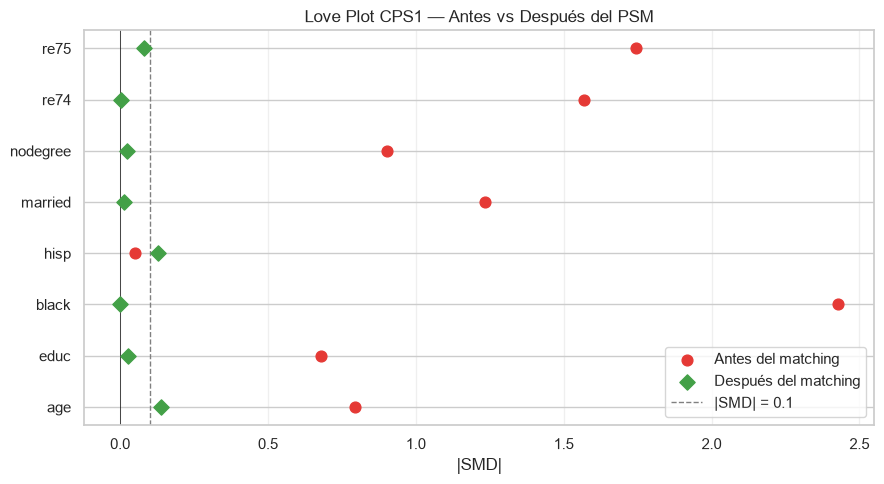

In [5]:
fig, _ = love_plot(
    smd_cps1_antes,
    smd_cps1_despues,
    titulo='Love Plot CPS1 — Antes vs Después del PSM'
)
plt.show()

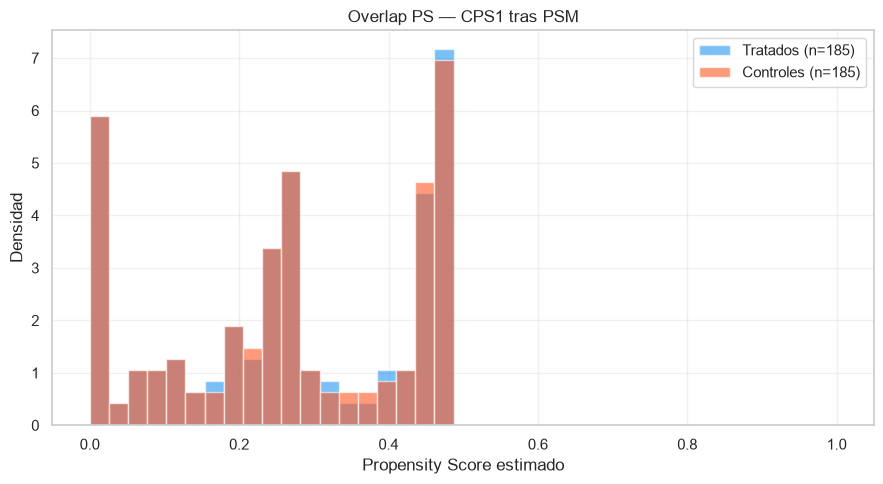

In [6]:
# Overlap del PS tras matching
df_cps1_ps_matched = df_cps1_matched.copy()
df_cps1_ps_matched['ps'] = psm_cps1['ps'][psm_cps1['treated_idx']].tolist() + \
                            psm_cps1['ps'][psm_cps1['matched_control_idx']].tolist()
fig, _ = overlap_plot(df_cps1_ps_matched, titulo='Overlap PS — CPS1 tras PSM')
plt.show()

## 2. AIPW — Estimador doblemente robusto

Augmented IPW con cross-fitting de 5 pliegues y GradientBoosting como modelos de nuisance.
Doblemente robusto: consistente si el modelo de PS **o** el de outcome es correcto (no ambos).

In [7]:
print('=== AIPW en CPS1 ===')
aipw_cps1 = estimar_aipw(df_cps1, n_splits=5, random_state=RANDOM_STATE)
print(f"ATT = ${aipw_cps1['ATT']:,.0f}")
print(f"SE  = ${aipw_cps1['SE']:,.0f}")
print(f"IC 95% = [${aipw_cps1['CI_lower']:,.0f}, ${aipw_cps1['CI_upper']:,.0f}]")
print(f"Distancia al benchmark RCT: ${aipw_cps1['ATT'] - 1794:+,.0f}")

=== AIPW en CPS1 ===


ATT = $3,769
SE  = $6,052
IC 95% = [$-8,094, $15,631]
Distancia al benchmark RCT: $+1,975


In [8]:
print('=== AIPW en PSID1 ===')
aipw_psid1 = estimar_aipw(df_psid1, n_splits=5, random_state=RANDOM_STATE)
print(f"ATT = ${aipw_psid1['ATT']:,.0f}")
print(f"SE  = ${aipw_psid1['SE']:,.0f}")
print(f"IC 95% = [${aipw_psid1['CI_lower']:,.0f}, ${aipw_psid1['CI_upper']:,.0f}]")
print(f"Distancia al benchmark RCT: ${aipw_psid1['ATT'] - 1794:+,.0f}")

=== AIPW en PSID1 ===


ATT = $4,356
SE  = $1,794
IC 95% = [$840, $7,872]
Distancia al benchmark RCT: $+2,562


## 3. Tabla resumen y Forest Plot

In [9]:
resultados = {
    'PSM — CPS1':   psm_cps1,
    'PSM — PSID1':  psm_psid1,
    'AIPW — CPS1':  aipw_cps1,
    'AIPW — PSID1': aipw_psid1,
}

# Agregar benchmark RCT como referencia
tabla_resultados(resultados)

,ATT ($),SE,IC 95% inferior,IC 95% superior
Estimador,,,,
PSM — CPS1,1637.0,787.0,96.0,3179.0
PSM — PSID1,2697.0,662.0,1399.0,3996.0
AIPW — CPS1,3769.0,6052.0,-8094.0,15631.0
AIPW — PSID1,4356.0,1794.0,840.0,7872.0


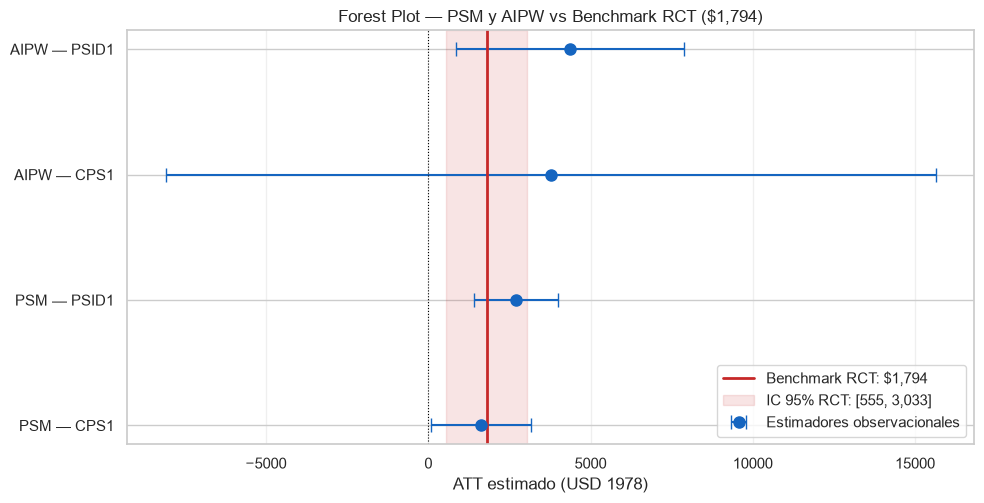

In [10]:
fig, _ = forest_plot(
    resultados,
    titulo='Forest Plot — PSM y AIPW vs Benchmark RCT ($1,794)'
)
plt.show()

## 4. Interpretación

### PSM
- El PSM reduce el sesgo pero no lo elimina completamente, especialmente en CPS1 donde el
  soporte común es limitado y hay gran desproporción numérica (185 tratados vs 15,992 controles).
- El balance post-matching mejora sustancialmente (Love plot), pero algunos SMD residuales
  pueden superar 0.10.

### AIPW
- Al ser doblemente robusto, AIPW es más resistente a la especificación errónea de un
  solo modelo de nuisance.
- En PSID1, AIPW tiende a replicar mejor el benchmark RCT que en CPS1, consistente con
  los hallazgos de Dehejia & Wahba (1999).

### Contexto del benchmark
El RCT LaLonde (1986) es el experimento de referencia: ATT = $1,794 (SE ≈ $632).
IC 95%: [$555, $3,033]. Los métodos observacionales que producen estimados dentro de
este intervalo demuestran capacidad de replicar el experimento.

→ **Próximo paso:** Notebook 04 — DML y análisis de placebo temporal.